# Baseline — Gradient Boosting

Outro ensemble de árvores, geralmente o topo em dados tabulares. Grid search no mesmo CV.

## Setup

In [1]:
import os, sys
# garante o cwd na raiz do repo (onde ficam data/ e support_scripts/)
while not os.path.isdir('support_scripts') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.append('support_scripts')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import data_prep as dp, sk_eval

d = dp.get_data()
print(f"{len(d['df'])} animais | {len(d['scale_cols'])} preditores | "
      f"{d['groups'].value_counts().to_dict()}")
from sklearn.ensemble import GradientBoostingRegressor
from itertools import product

245 animais | 9 preditores | {'elvis': 113, 'humberto': 71, 'sonico': 61}


## Grid search (CV 10-fold)

In [2]:
gb_grid = dict(n_estimators=[300], max_depth=[2, 3],
               learning_rate=[0.03, 0.05, 0.1], subsample=[1.0, 0.8])
rows, cfgs = [], []
for vals in product(*gb_grid.values()):
    p = dict(zip(gb_grid, vals)); cfgs.append(p)
    cv = sk_eval.cv_eval(d, lambda p=p: GradientBoostingRegressor(**p, random_state=dp.SEED),
                         scale=False)
    rows.append({**p, 'R2': round(cv.R2.mean(), 4), 'MAE': round(cv.MAE.mean(), 4)})
best_gb = cfgs[int(np.argmax([r['R2'] for r in rows]))]   # da lista (tipos preservados)
gb_res = pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)
print('melhor GB:', best_gb)
gb_res

melhor GB: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8}


,n_estimators,max_depth,learning_rate,subsample,R2,MAE
0,300,3,0.10,0.8,0.4920,0.0513
1,300,3,0.05,0.8,0.4919,0.0530
2,300,2,0.10,0.8,0.4883,0.0534
3,300,2,0.05,0.8,0.4835,0.0557
4,300,3,0.03,0.8,0.4771,0.0548
5,300,3,0.03,1.0,0.4717,0.0566
6,300,2,0.10,1.0,0.4669,0.0560
7,300,2,0.03,1.0,0.4660,0.0581
8,300,3,0.10,1.0,0.4655,0.0540
9,300,3,0.05,1.0,0.4601,0.0564


## CV + LOPO do melhor GB (grava no comparativo)

In [3]:
mk_gb = lambda: GradientBoostingRegressor(**best_gb, random_state=dp.SEED)
res = sk_eval.registrar('GradientBoosting', mk_gb, scale=False, d=d)
res['lopo']

GradientBoosting: CV R2 sem=0.492 / com jitter=0.503  | MAE=0.0513
  LOPO R2: {'elvis': -0.25, 'sonico': -3.11, 'humberto': 0.47}


,testa,MAE,RMSE,R2
0,elvis,0.0822,0.1025,-0.2523
1,sonico,0.1168,0.1527,-3.1072
2,humberto,0.0818,0.1213,0.4723


## Predito × real (out-of-fold)

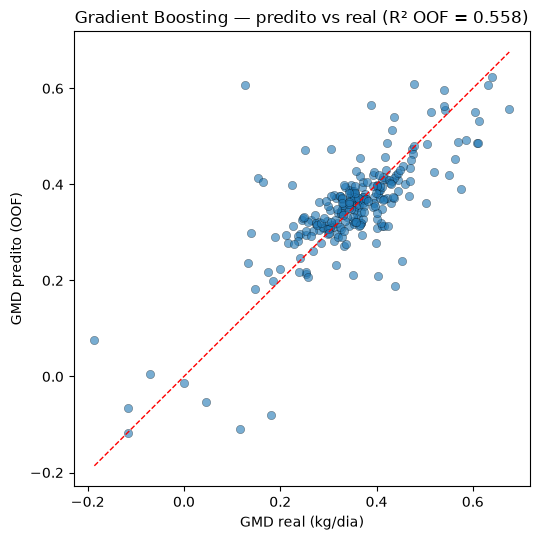

In [4]:
y = d['df'][dp.TARGET].values
yp = sk_eval.oof(d, mk_gb, scale=False)
r2 = dp.metrics(y, yp)['R2']
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(y, yp, alpha=.6, edgecolor='k', linewidth=.3)
lims = [min(y.min(), yp.min()), max(y.max(), yp.max())]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('GMD real (kg/dia)'); ax.set_ylabel('GMD predito (OOF)')
ax.set_title(f'Gradient Boosting — predito vs real (R² OOF = {r2:.3f})')
plt.tight_layout(); plt.show()